<a href="https://colab.research.google.com/github/RiccoFlores/100-Days-Of-ML-Code/blob/master/NB3_1_Introducci%C3%B3n_a_Redes_Neuronales_con_Tensorflow_y_Keras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introducción a Redes Neuronales con Tensorflow y Keras

## Introducción

En esta libreta exploraremos diferentes arquitecturas de Redes Neuronales con Tensorflow/Keras para predecir el rendimiento de estudiantes. El conjunto de datos fue obtenido del siguiente [enlace](https://www.kaggle.com/datasets/rabieelkharoua/students-performance-dataset?).

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

import tensorflow as tf
from tensorflow import keras

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score, confusion_matrix, classification_report, f1_score, precision_score, recall_score

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
path_file = '/content/drive/MyDrive/Instituto Tecnológico de Petróleo y Energía/Diplomado en Ciencia de Datos y Aplicaciones en IA/Módulo 3/Libretas/data/Student_Performance.csv'

In [ ]:
df = pd.read_csv(path_file)
df.head()

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0


In [ ]:
df.shape

(2392, 15)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2392 entries, 0 to 2391
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   StudentID          2392 non-null   int64  
 1   Age                2392 non-null   int64  
 2   Gender             2392 non-null   int64  
 3   Ethnicity          2392 non-null   int64  
 4   ParentalEducation  2392 non-null   int64  
 5   StudyTimeWeekly    2392 non-null   float64
 6   Absences           2392 non-null   int64  
 7   Tutoring           2392 non-null   int64  
 8   ParentalSupport    2392 non-null   int64  
 9   Extracurricular    2392 non-null   int64  
 10  Sports             2392 non-null   int64  
 11  Music              2392 non-null   int64  
 12  Volunteering       2392 non-null   int64  
 13  GPA                2392 non-null   float64
 14  GradeClass         2392 non-null   float64
dtypes: float64(3), int64(12)
memory usage: 280.4 KB


In [ ]:
df.isnull().sum()

,0
StudentID,0
Age,0
Gender,0
Ethnicity,0
ParentalEducation,0
StudyTimeWeekly,0
Absences,0
Tutoring,0
ParentalSupport,0
Extracurricular,0


## Exploración de Datos

In [ ]:
df.head()

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0


In [ ]:
numeric_variables = ['Age', 'StudyTimeWeekly', 'Absences']
categorical_nominal_variables = ['Ethnicity']
categorical_ordinal_variables = ['ParentalEducation', 'ParentalSupport']
binary_variables = ['Gender', 'Tutoring', 'Extracurricular', 'Sports', 'Music', 'Volunteering']
target_numeric = 'GPA'
target_categorical = 'GradeClass'

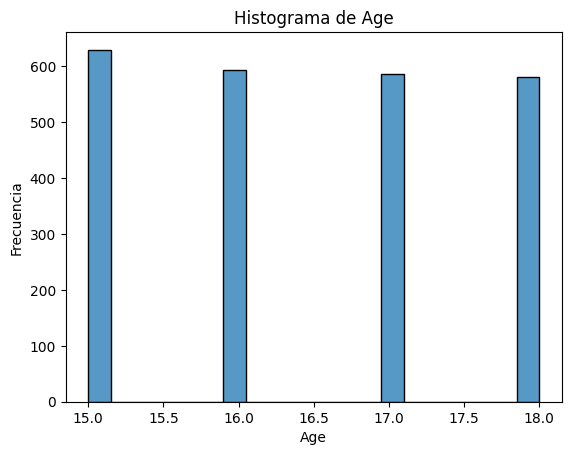

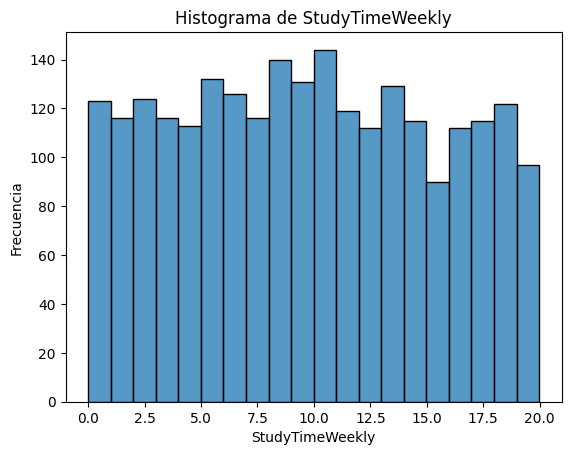

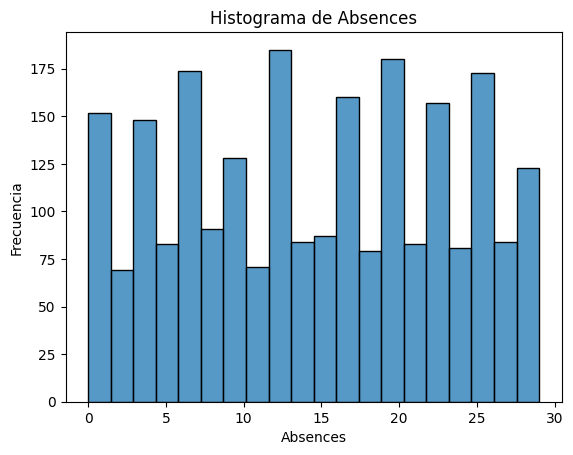

In [ ]:
# Variables Numéricas -> Histogramas
for col in numeric_variables:
  plt.figure()
  sns.histplot(df[col], bins = 20)
  plt.title(f'Histograma de {col}')
  plt.xlabel(col)
  plt.ylabel('Frecuencia')
  plt.show()

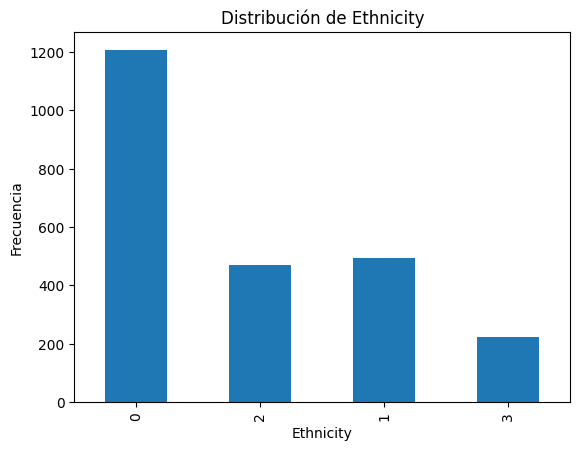

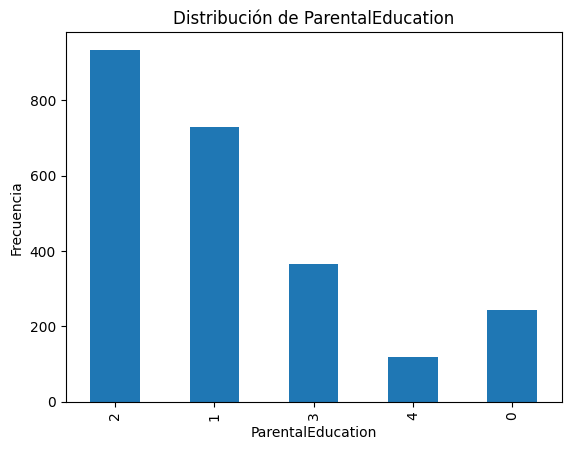

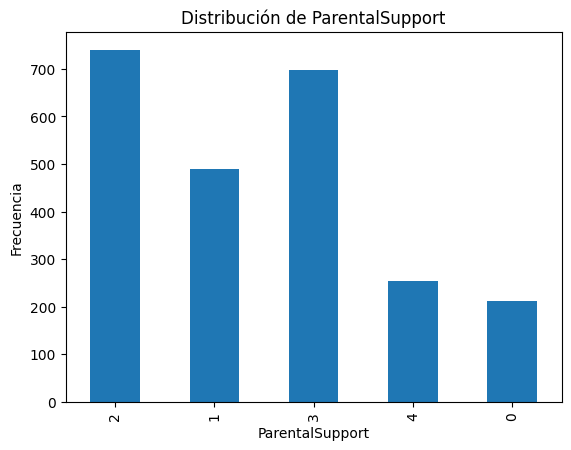

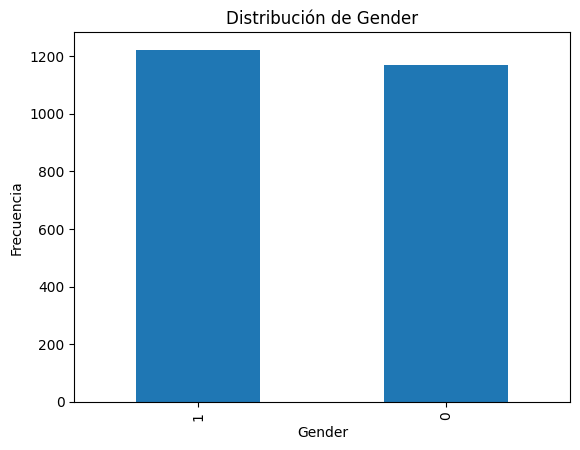

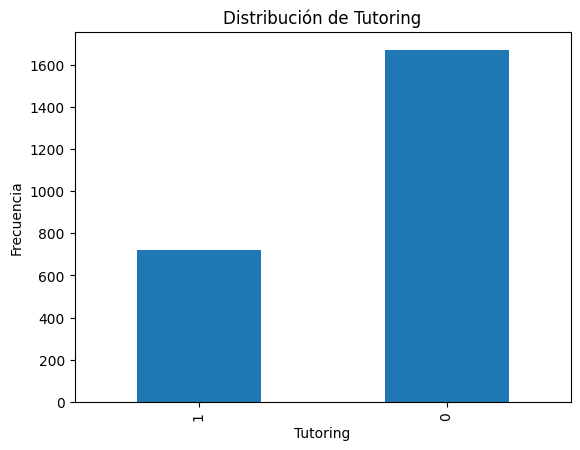

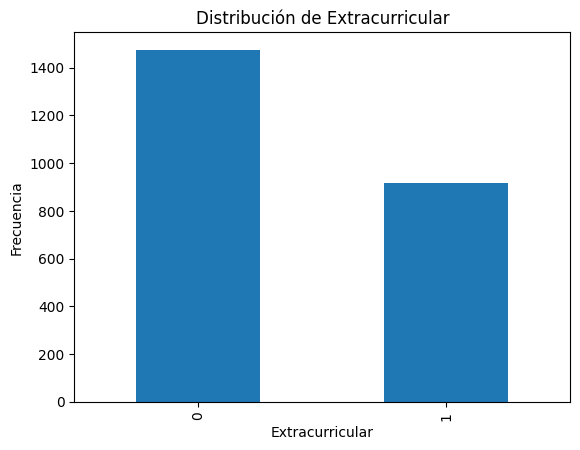

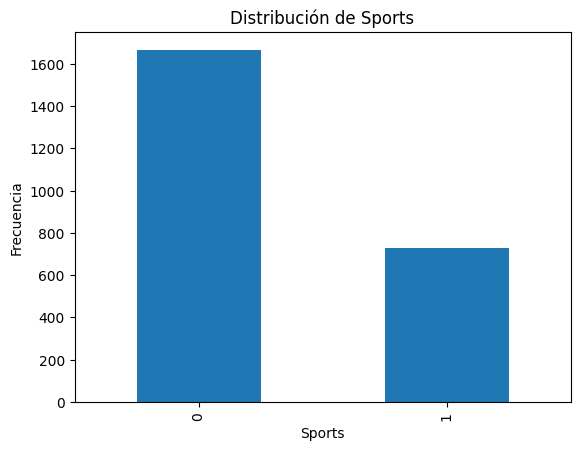

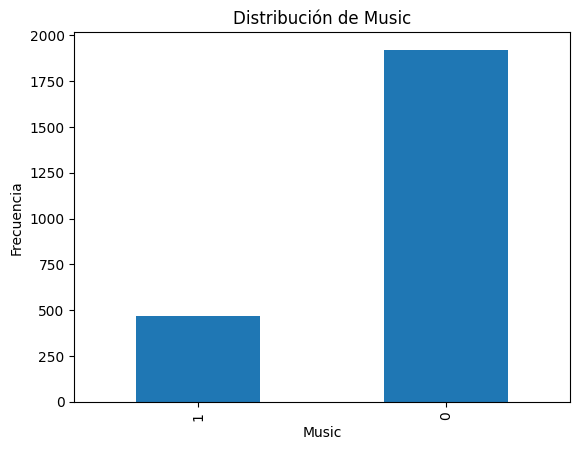

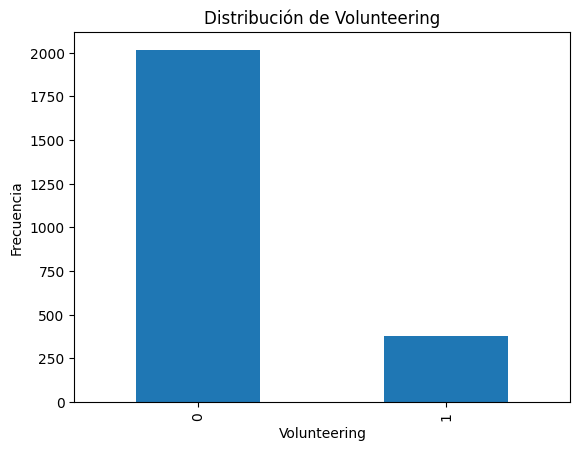

In [ ]:
# Variables Categóricas (Ordinales, Nominales, Binarias)

categorical_variables = categorical_nominal_variables + categorical_ordinal_variables + binary_variables

for col in categorical_variables:
  plt.figure()
  df[col].value_counts(sort = False).plot(kind = 'bar')
  plt.title(f'Distribución de {col}')
  plt.xlabel(col)
  plt.ylabel('Frecuencia')
  plt.show()

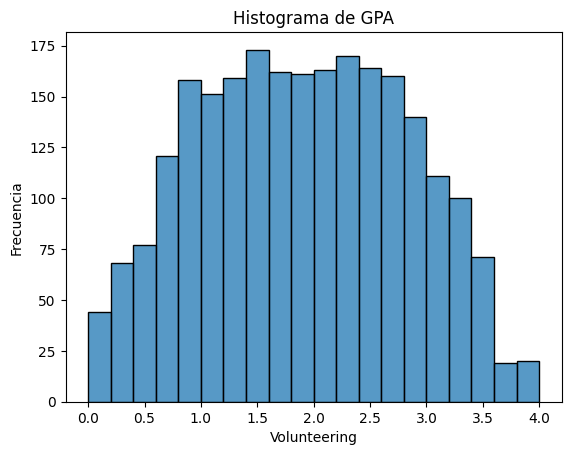

In [ ]:
# Distribución de la Variable Objetivo (Numérica)
plt.figure()
sns.histplot(df[target_numeric], bins = 20)
plt.title(f'Histograma de {target_numeric}')
plt.xlabel(col)
plt.ylabel('Frecuencia')
plt.show()

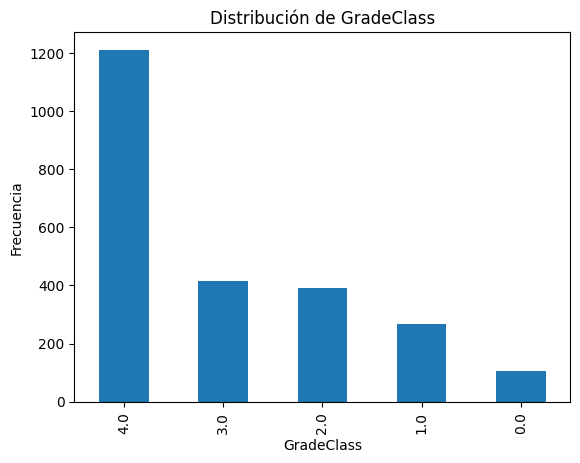

In [ ]:
# Variable Objetivo (Categórica)
plt.figure()
df[target_categorical].value_counts().plot(kind = 'bar')
plt.title(f'Distribución de {target_categorical}')
plt.xlabel(target_categorical)
plt.ylabel('Frecuencia')
plt.show()

## Procesamiento

In [ ]:
# Identificar variables predictoras (X) y generar nuestras variables objetivo
# y_reg -> Regresión
# y_clf_binary -> Clasificación
# y_clf_multiclass -> Clasificación Multiclase

X = df.drop(columns = [target_numeric, target_categorical])
y_reg = df[target_numeric]
y_clf_binary = (df[target_numeric] >= 3.5).astype(int)
y_clf_multiclass = df[target_categorical].astype(int)

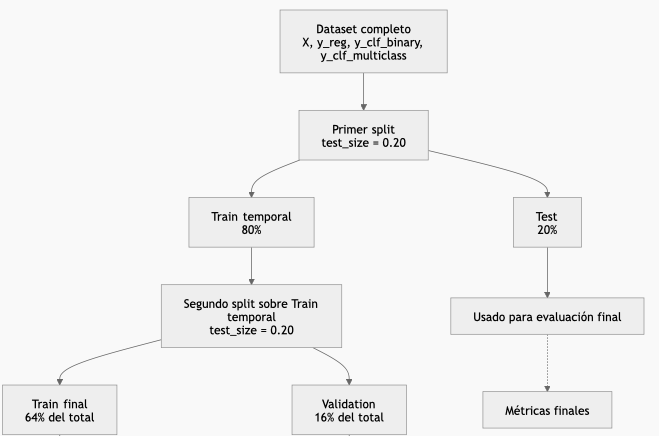

In [ ]:
# Dividir los conjuntos de datos
# train -> Entrenamiento
# val   -> Validar durante el entrenamiento
# test  -> Evaluación

# División en 100% -> Train 80%, Test 20%
X_train, X_test, y_reg_train, y_reg_test, y_bin_train, y_bin_test, y_multi_train, y_multi_test = train_test_split(
    X,
    y_reg,
    y_clf_binary,
    y_clf_multiclass,
    test_size=0.2,
    random_state=42
)

# División en Train 80% -> Train 64%, Val 16%
X_train, X_val, y_reg_train, y_reg_val, y_bin_train, y_bin_val, y_multi_train, y_multi_val = train_test_split(
    X_train,
    y_reg_train,
    y_bin_train,
    y_multi_train,
    test_size=0.2,
    random_state=42
)

In [ ]:
# Procesamiento
# numeric       -> StandardScaler
# cat nominal   -> OneHotEncoder
# cat ordinales -> StandarScaler
# binary        -> Nada
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_variables + categorical_ordinal_variables),
        ('nom', OneHotEncoder(drop = 'first', sparse_output = False), categorical_nominal_variables),
        ('bin', 'passthrough', binary_variables)
    ]
)

X_train_scaled = preprocessor.fit_transform(X_train)
X_val_scaled = preprocessor.transform(X_val)
X_test_scaled = preprocessor.transform(X_test)

In [ ]:
preprocessor

ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['Age', 'StudyTimeWeekly', 'Absences',
                                  'ParentalEducation', 'ParentalSupport']),
                                ('nom',
                                 OneHotEncoder(drop='first',
                                               sparse_output=False),
                                 ['Ethnicity']),
                                ('bin', 'passthrough',
                                 ['Gender', 'Tutoring', 'Extracurricular',
                                  'Sports', 'Music', 'Volunteering'])])

De modo que así queda distribuido:

Entrenamiento

1,530  - 64%

Validación

383    - 16%

Evaluación

479    - 20%

2,392 - Total de Registros

In [ ]:
X_train_scaled.shape, X_val_scaled.shape, X_test_scaled.shape

((1530, 14), (383, 14), (479, 14))

## Regresión Lineal con Tensorflow



In [ ]:
X_train_scaled.shape[1]

14

In [ ]:
linear_regression_model = keras.models.Sequential([
    keras.layers.Input(shape = (X_train_scaled.shape[1],)),
    keras.layers.Dense(1)
])

In [ ]:
linear_regression_model.compile(
    optimizer = keras.optimizers.SGD(learning_rate = 1e-3),
    loss = 'mse',
    metrics = [
      keras.metrics.RootMeanSquaredError(name = 'rmse'),
      keras.metrics.MeanAbsoluteError(name = 'mae')
    ]
)

In [ ]:
linear_regression_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │            15 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15 (60.00 B)

 Trainable params: 15 (60.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stopping_linear = keras.callbacks.EarlyStopping(
    monitor = 'val_loss',
    patience = 10,
    restore_best_weights = True
)

In [ ]:
history_linear = linear_regression_model.fit(
    X_train_scaled,
    y_reg_train,
    validation_data = (X_val_scaled, y_reg_val),
    epochs = 500,
    batch_size = 32,
    callbacks = [early_stopping_linear]
    #verbose = 0
)

Epoch 1/500
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 3.5365 - mae: 1.6609 - rmse: 1.8806 - val_loss: 2.8699 - val_mae: 1.4586 - val_rmse: 1.6941
Epoch 2/500
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.6608 - mae: 1.4200 - rmse: 1.6312 - val_loss: 2.1689 - val_mae: 1.2492 - val_rmse: 1.4727
Epoch 3/500
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.0298 - mae: 1.2226 - rmse: 1.4247 - val_loss: 1.6643 - val_mae: 1.0785 - val_rmse: 1.2901
Epoch 4/500
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.5731 - mae: 1.0640 - rmse: 1.2542 - val_loss: 1.3000 - val_mae: 0.9429 - val_rmse: 1.1402
Epoch 5/500
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.2413 - mae: 0.9337 - rmse: 1.1141 - val_loss: 1.0345 - val_mae: 0.8358 - val_rmse: 1.0171
Epoch 6/500
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9980 - mae: 0.8292 - rmse: 0.9990 - val_loss: 0.8402 - val_mae: 0.7484 - val_rmse: 0.9166
Epoch 7/500
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.8187 - mae: 0.7453 - rmse: 0.904

In [ ]:
pd.DataFrame(history_linear.history).head()

,loss,mae,rmse,val_loss,val_mae,val_rmse
0,3.536521,1.660926,1.880564,2.869941,1.458603,1.694090
1,2.660809,1.419998,1.631199,2.168933,1.249247,1.472730
2,2.029840,1.222633,1.424725,1.664316,1.078466,1.290084
3,1.573107,1.063972,1.254236,1.299986,0.942925,1.140169
4,1.241252,0.933689,1.114115,1.034472,0.835807,1.017090


In [ ]:
pd.DataFrame(history_linear.history).shape

(500, 6)

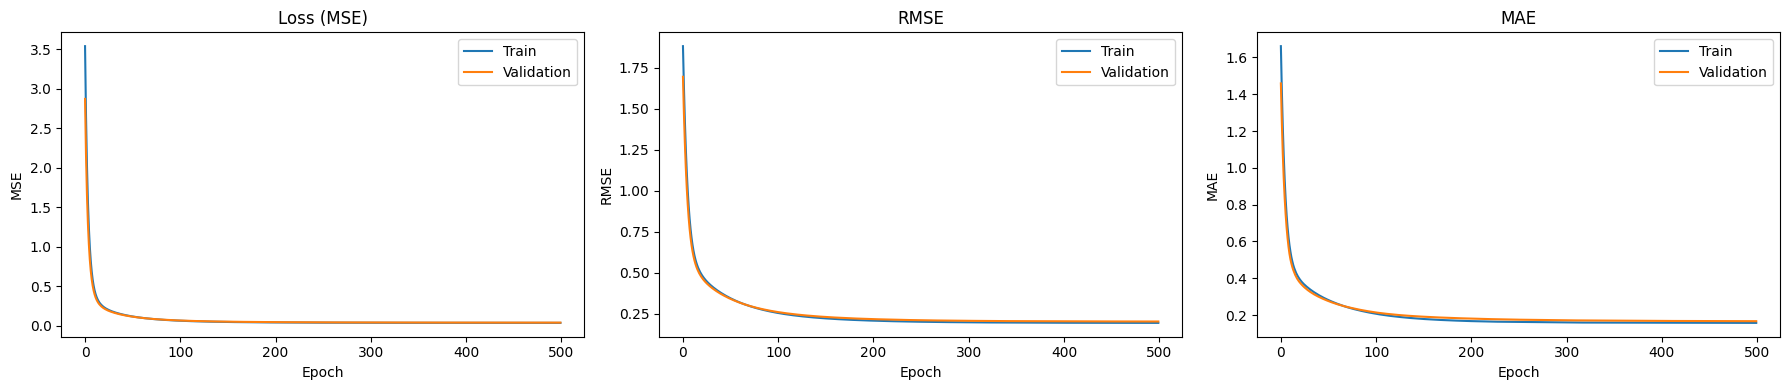

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(history_linear.history["loss"], label="Train")
axes[0].plot(history_linear.history["val_loss"], label="Validation")
axes[0].set_title("Loss (MSE)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE")
axes[0].legend()

axes[1].plot(history_linear.history["rmse"], label="Train")
axes[1].plot(history_linear.history["val_rmse"], label="Validation")
axes[1].set_title("RMSE")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("RMSE")
axes[1].legend()

axes[2].plot(history_linear.history["mae"], label="Train")
axes[2].plot(history_linear.history["val_mae"], label="Validation")
axes[2].set_title("MAE")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("MAE")
axes[2].legend()

plt.tight_layout()
plt.show()

In [ ]:
# Evaluación
y_pred_linear = linear_regression_model.predict(X_test_scaled).flatten()

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step


In [ ]:
rmse_linear = np.sqrt(mean_squared_error(y_reg_test, y_pred_linear))
mae_linear = mean_absolute_error(y_reg_test, y_pred_linear)
r2_linear = r2_score(y_reg_test, y_pred_linear)

print(f"RMSE: {rmse_linear:.4f}")
print(f"MAE:  {mae_linear:.4f}")
print(f"R2:   {r2_linear:.4f}")

RMSE: 0.1983
MAE:  0.1567
R2:   0.9525


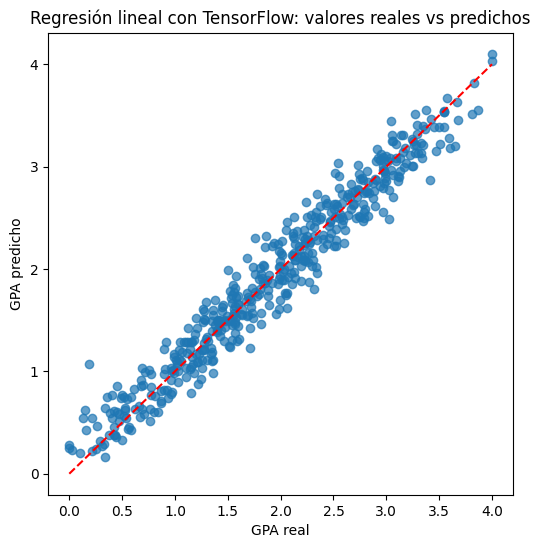

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(y_reg_test, y_pred_linear, alpha=0.7)
plt.plot(
    [y_reg_test.min(), y_reg_test.max()],
    [y_reg_test.min(), y_reg_test.max()],
    "r--"
)
plt.xlabel("GPA real")
plt.ylabel("GPA predicho")
plt.title("Regresión lineal con TensorFlow: valores reales vs predichos")
plt.show()

## Regresión Logística con Tensorflow

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

In [ ]:
classes = np.unique(y_bin_train)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_bin_train
)

class_weight_dict = dict(zip(classes, class_weights))

print(class_weight_dict)

{np.int64(0): np.float64(0.5179417738659445), np.int64(1): np.float64(14.433962264150944)}


In [ ]:
logistic_regression_model = keras.models.Sequential([
    keras.layers.Input(shape = (X_train_scaled.shape[1],)),
    keras.layers.Dense(1, activation = 'sigmoid')
])

In [ ]:
logistic_regression_model.compile(
    optimizer = keras.optimizers.SGD(learning_rate = 1e-3),
    loss = 'binary_crossentropy',
    metrics = [
        keras.metrics.BinaryAccuracy(name = 'accuracy'),
        keras.metrics.Precision(name = 'precision'),
        keras.metrics.Recall(name = 'recall')
    ]
)

In [ ]:
logistic_regression_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 1)              │            15 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15 (60.00 B)

 Trainable params: 15 (60.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stopping_logistic = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history_logistic = logistic_regression_model.fit(
    X_train_scaled,
    y_bin_train,
    validation_data=(X_val_scaled, y_bin_val),
    epochs=200,
    batch_size=32,
    callbacks=[early_stopping_logistic],
    class_weight = class_weight_dict
)

Epoch 1/200
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6007 - loss: 1.2193 - precision: 0.0018 - recall: 0.0189 - val_accuracy: 0.6397 - val_loss: 0.6387 - val_precision: 0.0076 - val_recall: 0.1250
Epoch 2/200
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6013 - loss: 1.1838 - precision: 0.0018 - recall: 0.0189 - val_accuracy: 0.6397 - val_loss: 0.6404 - val_precision: 0.0076 - val_recall: 0.1250
Epoch 3/200
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5941 - loss: 1.1498 - precision: 0.0018 - recall: 0.0189 - val_accuracy: 0.6345 - val_loss: 0.6423 - val_precision: 0.0075 - val_recall: 0.1250
Epoch 4/200
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5922 - loss: 1.1171 - precision: 0.0017 - recall: 0.0189 - val_accuracy: 0.6292 - val_loss: 0.6444 - val_precision: 0.0074 - val_recall: 0.1250
Epoch 5/200
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5915 - loss: 1.0860 - precision: 0.0017 - recall: 0.0189 - val_accuracy: 0.6214 - val_loss: 0.6464

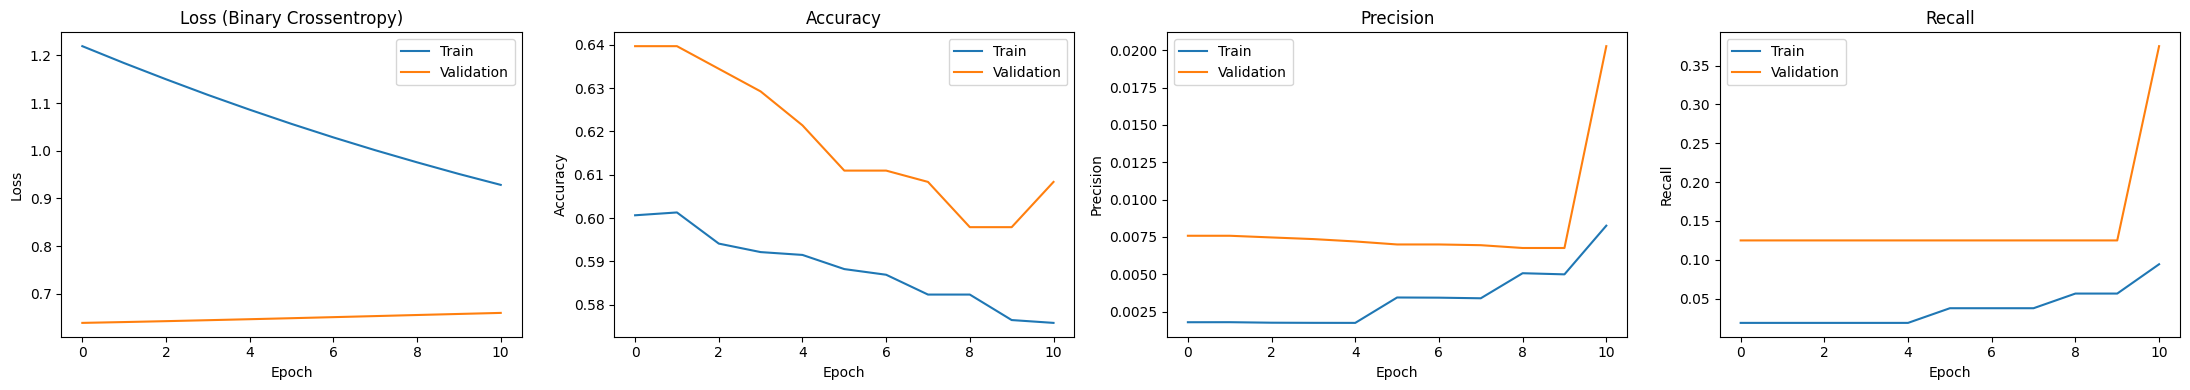

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(22, 4))

axes[0].plot(history_logistic.history["loss"], label="Train")
axes[0].plot(history_logistic.history["val_loss"], label="Validation")
axes[0].set_title("Loss (Binary Crossentropy)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(history_logistic.history["accuracy"], label="Train")
axes[1].plot(history_logistic.history["val_accuracy"], label="Validation")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

axes[2].plot(history_logistic.history["precision"], label="Train")
axes[2].plot(history_logistic.history["val_precision"], label="Validation")
axes[2].set_title("Precision")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Precision")
axes[2].legend()

axes[3].plot(history_logistic.history["recall"], label="Train")
axes[3].plot(history_logistic.history["val_recall"], label="Validation")
axes[3].set_title("Recall")
axes[3].set_xlabel("Epoch")
axes[3].set_ylabel("Recall")
axes[3].legend()

plt.tight_layout()
plt.show()

In [ ]:
y_pred_prob_logistic = logistic_regression_model.predict(X_test_scaled).flatten()
y_pred_logistic = (y_pred_prob_logistic >= 0.5).astype(int)

acc_logistic = accuracy_score(y_bin_test, y_pred_logistic)

print(f"Accuracy: {acc_logistic:.4f}")
print(confusion_matrix(y_bin_test, y_pred_logistic))
print(classification_report(y_bin_test, y_pred_logistic))

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Accuracy: 0.6430
[[307 156]
 [ 15   1]]
              precision    recall  f1-score   support

           0       0.95      0.66      0.78       463
           1       0.01      0.06      0.01        16

    accuracy                           0.64       479
   macro avg       0.48      0.36      0.40       479
weighted avg       0.92      0.64      0.76       479



## Red Neuronal para Regresión

In [ ]:
checkpoint_regression_path = "best_nn_regression_model.keras"

In [ ]:
nn_regression_model = keras.models.Sequential([
    keras.layers.Input(shape=(X_train_scaled.shape[1],)),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(1)
])

In [ ]:
nn_regression_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='mse',
    metrics=[
        keras.metrics.RootMeanSquaredError(name='rmse'),
        keras.metrics.MeanAbsoluteError(name='mae')
    ]
)

In [ ]:
nn_regression_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 32)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,025 (4.00 KB)

 Trainable params: 1,025 (4.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stopping_nn_reg = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

model_checkpoint_nn_reg = keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_regression_path,
    monitor='val_loss',
    save_best_only=True
)

In [ ]:
history_nn_reg = nn_regression_model.fit(
    X_train_scaled,
    y_reg_train,
    validation_data=(X_val_scaled, y_reg_val),
    epochs=500,
    batch_size=32,
    callbacks=[
        early_stopping_nn_reg,
        model_checkpoint_nn_reg
    ]
)

Epoch 1/500
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 3.3175 - mae: 1.5636 - rmse: 1.8214 - val_loss: 1.8829 - val_mae: 1.1294 - val_rmse: 1.3722
Epoch 2/500
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.3233 - mae: 0.9225 - rmse: 1.1503 - val_loss: 0.6462 - val_mae: 0.6413 - val_rmse: 0.8039
Epoch 3/500
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4804 - mae: 0.5592 - rmse: 0.6931 - val_loss: 0.2575 - val_mae: 0.4082 - val_rmse: 0.5074
Epoch 4/500
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2048 - mae: 0.3592 - rmse: 0.4526 - val_loss: 0.1489 - val_mae: 0.3111 - val_rmse: 0.3859
Epoch 5/500
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1322 - mae: 0.2902 - rmse: 0.3636 - val_loss: 0.1175 - val_mae: 0.2781 - val_rmse: 0.3428
Epoch 6/500
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1076 - mae: 0.2626 - rmse: 0.3280 - val_loss: 0.1016 - val_mae: 0.2590 - val_rmse: 0.3188
Epoch 7/500
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0948 - mae: 0.2474 - rmse: 0.3078

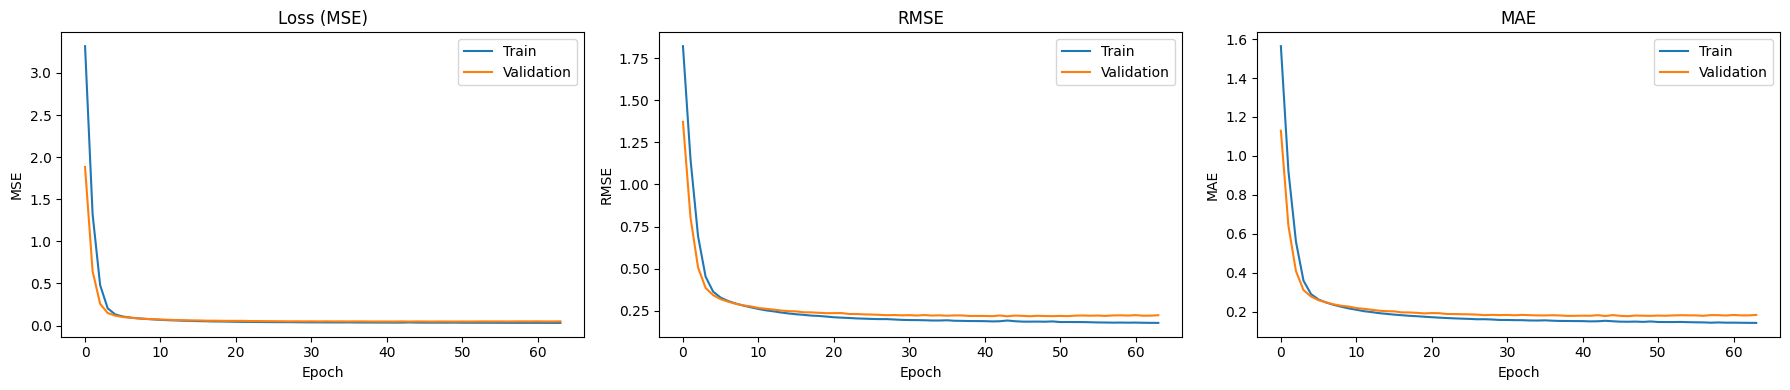

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(history_nn_reg.history["loss"], label="Train")
axes[0].plot(history_nn_reg.history["val_loss"], label="Validation")
axes[0].set_title("Loss (MSE)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE")
axes[0].legend()

axes[1].plot(history_nn_reg.history["rmse"], label="Train")
axes[1].plot(history_nn_reg.history["val_rmse"], label="Validation")
axes[1].set_title("RMSE")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("RMSE")
axes[1].legend()

axes[2].plot(history_nn_reg.history["mae"], label="Train")
axes[2].plot(history_nn_reg.history["val_mae"], label="Validation")
axes[2].set_title("MAE")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("MAE")
axes[2].legend()

plt.tight_layout()
plt.show()

In [ ]:
y_pred_nn_reg = nn_regression_model.predict(X_test_scaled).flatten()

rmse_nn_reg = np.sqrt(mean_squared_error(y_reg_test, y_pred_nn_reg))
mae_nn_reg = mean_absolute_error(y_reg_test, y_pred_nn_reg)
r2_nn_reg = r2_score(y_reg_test, y_pred_nn_reg)

print(f"RMSE: {rmse_nn_reg:.4f}")
print(f"MAE:  {mae_nn_reg:.4f}")
print(f"R2:   {r2_nn_reg:.4f}")

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
RMSE: 0.2195
MAE:  0.1732
R2:   0.9417


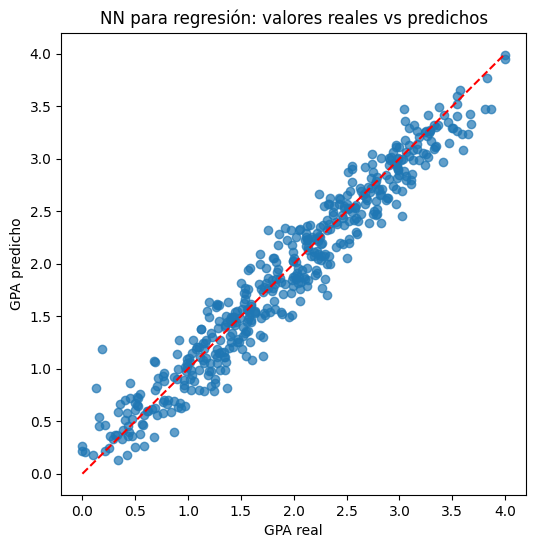

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(y_reg_test, y_pred_nn_reg, alpha=0.7)
plt.plot(
    [y_reg_test.min(), y_reg_test.max()],
    [y_reg_test.min(), y_reg_test.max()],
    "r--"
)
plt.xlabel("GPA real")
plt.ylabel("GPA predicho")
plt.title("NN para regresión: valores reales vs predichos")
plt.show()

## Red Neuronal para Clasificación Binaria

In [ ]:
nn_classification_model = keras.models.Sequential([
    keras.layers.Input(shape=(X_train_scaled.shape[1],)),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

In [ ]:
nn_classification_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=[
        keras.metrics.BinaryAccuracy(name='accuracy'),
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall')
    ]
)

In [ ]:
nn_classification_model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 64)             │           960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,073 (12.00 KB)

 Trainable params: 3,073 (12.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stopping_nn_clf = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=40,
    restore_best_weights=True
)

In [ ]:
history_nn_clf = nn_classification_model.fit(
    X_train_scaled,
    y_bin_train,
    validation_data=(X_val_scaled, y_bin_val),
    epochs=500,
    batch_size=32,
    callbacks=[early_stopping_nn_clf]
)

Epoch 1/500
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9582 - loss: 0.3338 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.9791 - val_loss: 0.1279 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/500
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9654 - loss: 0.1478 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.9791 - val_loss: 0.0886 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/500
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9654 - loss: 0.1228 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.9791 - val_loss: 0.0798 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/500
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9654 - loss: 0.1071 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.9791 - val_loss: 0.0747 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 5/500
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9654 - loss: 0.0948 - precision: 0

In [ ]:
history_nn_clf.history.keys()

dict_keys(['accuracy', 'loss', 'precision', 'recall', 'val_accuracy', 'val_loss', 'val_precision', 'val_recall'])

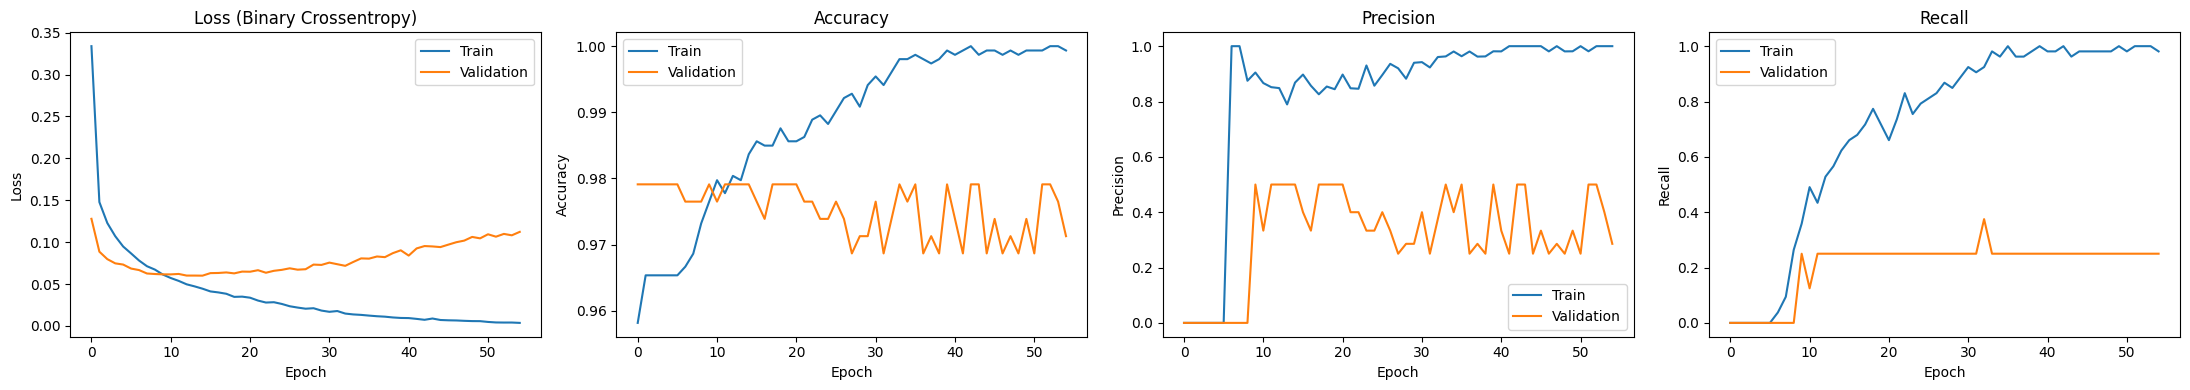

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(22, 4))

axes[0].plot(history_nn_clf.history["loss"], label="Train")
axes[0].plot(history_nn_clf.history["val_loss"], label="Validation")
axes[0].set_title("Loss (Binary Crossentropy)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(history_nn_clf.history["accuracy"], label="Train")
axes[1].plot(history_nn_clf.history["val_accuracy"], label="Validation")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

axes[2].plot(history_nn_clf.history["precision"], label="Train")
axes[2].plot(history_nn_clf.history["val_precision"], label="Validation")
axes[2].set_title("Precision")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Precision")
axes[2].legend()

axes[3].plot(history_nn_clf.history["recall"], label="Train")
axes[3].plot(history_nn_clf.history["val_recall"], label="Validation")
axes[3].set_title("Recall")
axes[3].set_xlabel("Epoch")
axes[3].set_ylabel("Recall")
axes[3].legend()

plt.tight_layout()
plt.show()

In [ ]:
y_pred_prob_nn_clf = nn_classification_model.predict(X_test_scaled).flatten()
y_pred_nn_clf = (y_pred_prob_nn_clf >= 0.5).astype(int)

acc_nn_clf = accuracy_score(y_bin_test, y_pred_nn_clf)

print(f"Accuracy: {acc_nn_clf:.4f}")
print(confusion_matrix(y_bin_test, y_pred_nn_clf))
print(classification_report(y_bin_test, y_pred_nn_clf))

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Accuracy: 0.9624
[[457   6]
 [ 12   4]]
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       463
           1       0.40      0.25      0.31        16

    accuracy                           0.96       479
   macro avg       0.69      0.62      0.64       479
weighted avg       0.96      0.96      0.96       479



In [ ]:
thresholds = np.linspace(0, 1, 100)

f1_scores = []
precision_scores = []
recall_scores = []

for t in thresholds:
    y_pred = (y_pred_prob_nn_clf >= t).astype(int)

    f1_scores.append(f1_score(y_bin_test, y_pred, zero_division=0))
    precision_scores.append(precision_score(y_bin_test, y_pred, zero_division=0))
    recall_scores.append(recall_score(y_bin_test, y_pred, zero_division=0))

# -----------------------------------
# Threshold óptimo según F1
# -----------------------------------
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Best threshold (F1): {best_threshold:.3f}")
print(f"Best F1-score: {f1_scores[best_idx]:.4f}")

Best threshold (F1): 0.182
Best F1-score: 0.4762


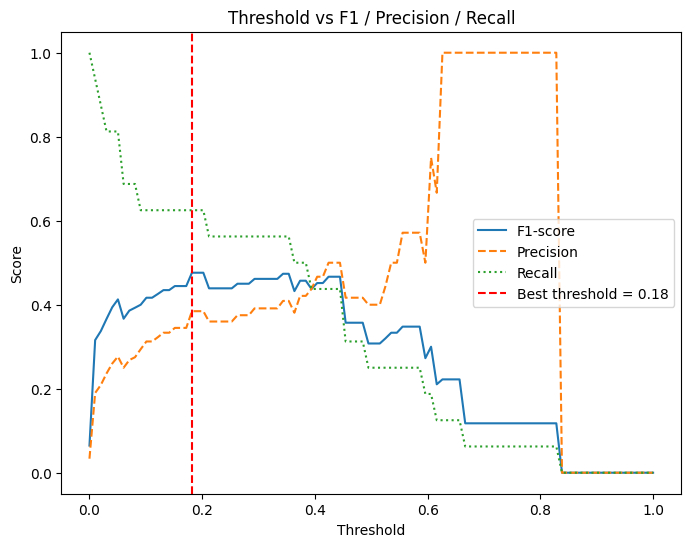

In [ ]:
plt.figure(figsize=(8,6))

plt.plot(thresholds, f1_scores, label='F1-score')
plt.plot(thresholds, precision_scores, label='Precision', linestyle='--')
plt.plot(thresholds, recall_scores, label='Recall', linestyle=':')

plt.axvline(best_threshold, color='red', linestyle='--', label=f'Best threshold = {best_threshold:.2f}')

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold vs F1 / Precision / Recall")
plt.legend()

plt.show()

In [ ]:
y_pred_opt = (y_pred_prob_nn_clf >= best_threshold).astype(int)

print(confusion_matrix(y_bin_test, y_pred_opt))
print(classification_report(y_bin_test, y_pred_opt))

[[447  16]
 [  6  10]]
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       463
           1       0.38      0.62      0.48        16

    accuracy                           0.95       479
   macro avg       0.69      0.80      0.73       479
weighted avg       0.97      0.95      0.96       479



## Red Neuronal Multiclase con Softmax

In [ ]:
num_classes = len(np.unique(y_multi_train))
num_classes

5

In [ ]:
nn_multiclass_model = keras.models.Sequential([
    keras.layers.Input(shape=(X_train_scaled.shape[1],)),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(num_classes, activation = 'softmax')
])

In [ ]:
nn_multiclass_model.compile(
    optimizer = keras.optimizers.Adam(learning_rate = 1e-3),
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

In [ ]:
nn_multiclass_model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 64)             │           960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,205 (12.52 KB)

 Trainable params: 3,205 (12.52 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stopping_nn_multi = keras.callbacks.EarlyStopping(
    monitor = 'val_loss',
    patience = 40,
    restore_best_weights = True
)

In [ ]:
history_nn_multi = nn_multiclass_model.fit(
    X_train_scaled,
    y_multi_train,
    validation_data = (X_val_scaled, y_multi_val),
    epochs = 500,
    batch_size = 32,
    callbacks = [early_stopping_nn_multi]
)

Epoch 1/500
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.4739 - loss: 1.3392 - val_accuracy: 0.6031 - val_loss: 1.0832
Epoch 2/500
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6261 - loss: 1.0037 - val_accuracy: 0.6736 - val_loss: 0.8849
Epoch 3/500
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6719 - loss: 0.8922 - val_accuracy: 0.6841 - val_loss: 0.8457
Epoch 4/500
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6987 - loss: 0.8492 - val_accuracy: 0.7076 - val_loss: 0.8164
Epoch 5/500
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7183 - loss: 0.8225 - val_accuracy: 0.7285 - val_loss: 0.8068
Epoch 6/500
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7229 - loss: 0.8044 - val_accuracy: 0.7363 - val_loss: 0.7936
Epoch 7/500
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7320 - loss: 0.7871 - val_accuracy: 0.7493 - val_loss: 0.7835
Epoch 8/500
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7399 - loss: 0.7726 - val_accuracy: 0.73

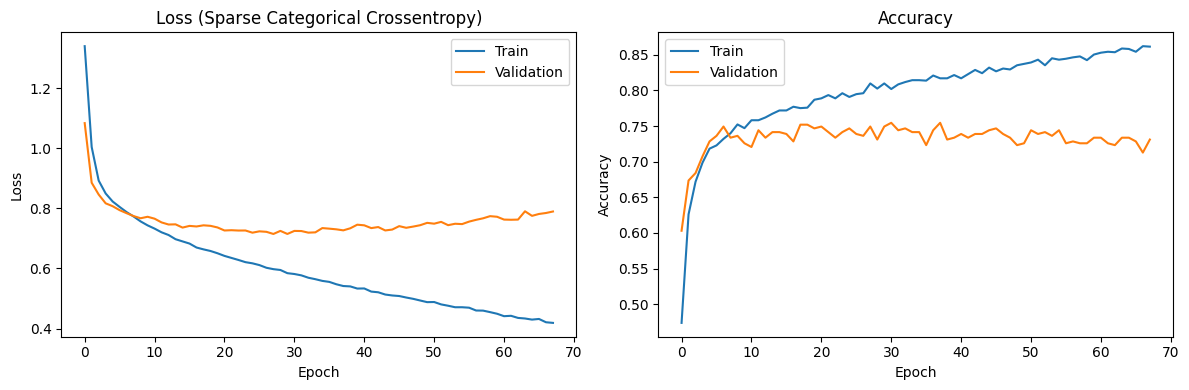

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_nn_multi.history["loss"], label="Train")
axes[0].plot(history_nn_multi.history["val_loss"], label="Validation")
axes[0].set_title("Loss (Sparse Categorical Crossentropy)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(history_nn_multi.history["accuracy"], label="Train")
axes[1].plot(history_nn_multi.history["val_accuracy"], label="Validation")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
y_pred_prob_nn_multi = nn_multiclass_model.predict(X_test_scaled)
y_pred_nn_multi = np.argmax(y_pred_prob_nn_multi, axis=1)

acc_nn_multi = accuracy_score(y_multi_test, y_pred_nn_multi)

print(f"Accuracy: {acc_nn_multi:.4f}")
print(confusion_matrix(y_multi_test, y_pred_nn_multi))
print(classification_report(y_multi_test, y_pred_nn_multi))

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Accuracy: 0.7015
[[  2  11   5   2   2]
 [  7  21  16   1   4]
 [  2  10  52  15   6]
 [  0   1  18  37  30]
 [  0   1   0  12 224]]
              precision    recall  f1-score   support

           0       0.18      0.09      0.12        22
           1       0.48      0.43      0.45        49
           2       0.57      0.61      0.59        85
           3       0.55      0.43      0.48        86
           4       0.84      0.95      0.89       237

    accuracy                           0.70       479
   macro avg       0.52      0.50      0.51       479
weighted avg       0.67      0.70      0.68       479



In [ ]:
y_pred_prob_nn_multi

array([[3.9290325e-04, 1.5947418e-03, 1.0116491e-03, 2.3189640e-01,
        7.6510423e-01],
       [1.2357266e-02, 1.6702083e-01, 6.8452573e-01, 1.2686032e-01,
        9.2357621e-03],
       [3.2092275e-03, 1.2575423e-02, 1.1245628e-02, 6.4104140e-02,
        9.0886545e-01],
       ...,
       [3.7347076e-03, 1.3588722e-01, 6.1202693e-01, 2.4067399e-01,
        7.6772184e-03],
       [2.7837905e-03, 5.8668822e-02, 4.8261049e-01, 4.2366034e-01,
        3.2276694e-02],
       [5.7902718e-03, 3.2884546e-02, 3.0452136e-03, 7.8206332e-03,
        9.5045936e-01]], dtype=float32)